# Deep Learning for Natural Language Processing - Exercise 2
## Author: Margarita Orfanidi ID: 7115152400023
The definition of ambiguity in the responses politicians give during interviews is a very challenging task in the field of NLP. Based on the dataset released for SemEval 2026 Task 6 (CLARITY), this assignment tries to explore this NLP problem by fine-tuning Transformer-based architectures. Specifically, this notebook explores the implementation and performance of the DeBERTa model.

The DeBERTa experiments were mainly exploratory, because the model showed instability during fine-tuning. Unlike the BERT and DistilBERT notebooks, where the goal was to compare several standard hyperparameter changes, the main goal here was to identify whether DeBERTa could be stabilized and whether it could become competitive with the previous models.

For this reason, the experiments progress from a simple baseline to more stable configurations using a lower learning rate, float32 precision, class-weighted loss, warm-up steps, and gradient clipping.

# Please Note

This notebook contains the final selected model and the code used to create the submission file.

To make the submission process easier and avoid unnecessary re-execution, the rest code cells have been commented out. As a result, some outputs may not be visible directly in the notebook. The corresponding results are reported in the final report.

If you want to inspect or reproduce any part of the process, please uncomment the relevant code cells and rerun them.

# Load Libraries

In [3]:
#!pip install transformers datasets torch scikit-learn sentencepiece tqdm \
# !pip uninstall -y torch torchvision torchaudio
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
#!pip install contractions pyspellchecker
import random 
import time
# import os

# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import sys
sys.path.append('/kaggle/input/datasets/leloulv/utils-exercise-2')
sys.path.append('/kaggle/input/datasets/leloulv/exercise1-nlp')
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler,DataCollatorWithPadding
from transformers import  logging
from tqdm.auto import tqdm
from datasets import load_dataset
from torch.optim import AdamW
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from torch.utils.data import  WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from utils import *
from helper_functions import *
set_seed(seed=42)

# Load dataset and Preprocessing

In this notebook, DeBERTa was tested as an alternative transformer-based model for the clarity classification task. The goal was to examine whether a stronger pretrained language model could improve the classification performance compared to the BERT-based experiments.

However, during fine-tuning, DeBERTa showed several training stability issues. The first experiments produced NaN losses, while later experiments became more stable but still failed to separate the three classes effectively. For this reason, the following experiments focus on understanding these issues and testing possible stabilization techniques.




Before training, a few simple preprocessing steps were applied. First, the question and interview_answer columns in both the training and test sets were explicitly cast to string type to prevent any type-related errors during tokenization. Second, any duplicate rows, based on a combination of the question, interview_answer, and clarity_label columns, were removed from the training set, ensuring that no identical question-answer-label triplets appeared more than once. Finally, the categorical clarity_label column was mapped to numeric integer labels — Clear Reply as 0, Ambivalent as 1, and Clear Non-Reply as 2 — as PyTorch requires class labels to be represented as integers rather than strings when computing loss during training.

Additional cleaning steps, such as stop word removal, were also explored but ultimately discarded, as they did not yield any noticeable improvement and risked stripping semantically relevant content from the interview responses.

In [4]:
# Load the dataset (train and test sets)
dataset = load_dataset("ailsntua/QEvasion")
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])
print("Original labels:", df_train['clarity_label'].unique())
# The mapping is important for the Bert ....
label_mapping = {
    "Clear Reply": 0,
    "Ambivalent": 1,
    "Clear Non-Reply": 2
}
# Apply the mapping to both train and test dataframes
df_train['labels'] = df_train['clarity_label'].map(label_mapping)
df_test['labels'] = df_test['clarity_label'].map(label_mapping)



#  text columns
df_train["question"] = df_train["question"].astype(str)
df_train["interview_answer"] = df_train["interview_answer"].astype(str)

df_test["question"] = df_test["question"].astype(str)
df_test["interview_answer"] = df_test["interview_answer"].astype(str)


# size before removing duplicates
print("Before drop_duplicates:", df_train.shape)

# remove duplicated rows based on question + answer + label
df_train = df_train.drop_duplicates(subset=["question", "interview_answer", "clarity_label"])

# size after removing duplicates
print("After drop_duplicates:", df_train.shape)


Original labels: ['Clear Reply' 'Ambivalent' 'Clear Non-Reply']
Before drop_duplicates: (3448, 21)
After drop_duplicates: (3402, 21)


In [5]:
device_manager = DeviceManager()
device_manager.summary()
device = device_manager.device


print("Python exe:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

Device type: cuda
Current GPU: Tesla T4
Using 2 GPUs with DataParallel
Python exe: /usr/bin/python3
Torch version: 2.10.0+cu128
Torch CUDA build: 12.8
CUDA available: True
GPU count: 2


In [6]:
# Model and Tokenizer
model_checkpoint =  "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

# Experiments

## Baseline DeBERTa Model

In Experiment 1, DeBERTa was tested using a baseline configuration similar to the initial BERT experiments. The model was fine-tuned using paired question-answer inputs with a maximum sequence length of 512 tokens. A batch size of 8, a learning rate of 2e-5, and 3 training epochs were used.

The purpose of this experiment was to establish an initial DeBERTa baseline and examine whether the model could be fine-tuned successfully for the three-class clarity classification task.

#### Experiment 1 
*Experimental Configuration*

The baseline configuration consists of:

- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score


 Starting Fold 1/4


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias        

Fold 1 Epoch 1:   0%|          | 0/319 [00:00<?, ?it/s]

...

Fold 4 Epoch 2:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 2: Train Loss nan | Val Loss nan | Val F1 0.1562


Fold 4 Epoch 3:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 3: Train Loss nan | Val Loss nan | Val F1 0.1562

 Overall Cross Validation Results  

Average Validation F1 Score: 0.1562 ± 0.0002

Fold execution times:
Fold 1: 5.51 minutes
Fold 2: 5.42 minutes
Fold 3: 5.44 minutes
Fold 4: 5.43 minutes

Total time for all 4 folds: 21.80 minutes
Average time per fold: 5.45 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.31      1.00      0.47      1041
           1       0.00      0.00      0.00      2009
           2       0.00      0.00      0.00       352

    accuracy                           0.31      3402
   macro avg       0.10      0.33      0.16      3402
weighted avg       0.09      0.31      0.14      3402



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


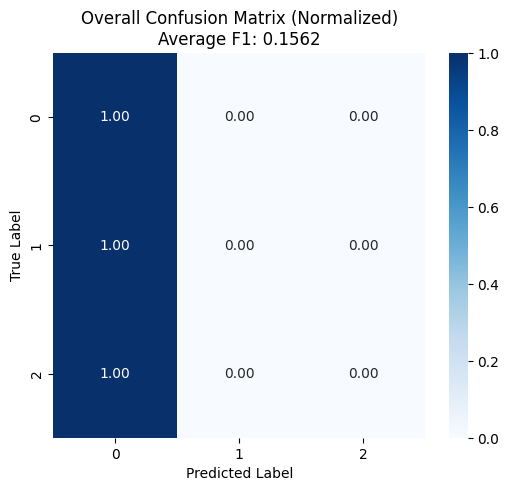


Cross-validation results
Fold F1s: [0.1564748201438849, 0.156015601560156, 0.15615615615615616, 0.15615615615615616]
Mean Macro F1: 0.1562
Std Macro F1: 0.0002


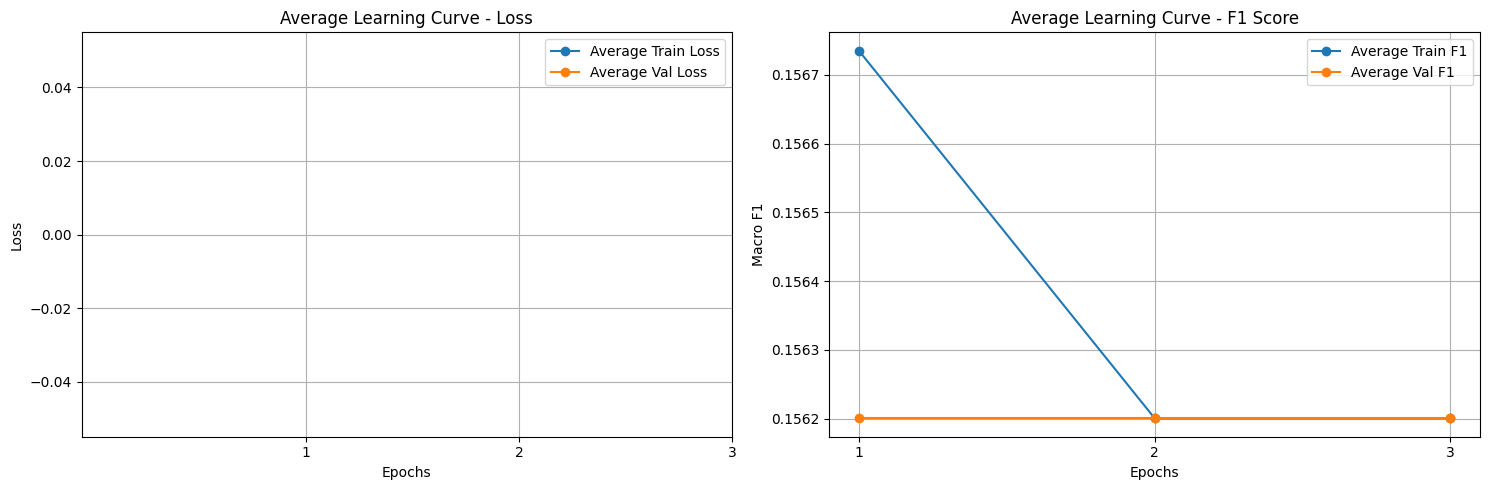

In [ ]:

# ==========================================
#  Experiment 1
# ==========================================

n_splits = 4
num_epochs = 3 # after 3 epoch is noticed overfitting
batch_size = 8
learning_rate = 2e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, # beacause as we saw at the token analysis there are many rows with larger that 512 tokens
        padding=True,
        max_length=512 # beacuse most of the tokens are grater that 512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



#### Conclusion

The baseline DeBERTa configuration was not successful. Both the training loss and the validation loss became NaN from the first epoch, showing that the training process was numerically unstable. As a result, the model did not learn meaningful decision boundaries between the classes.

The model achieved a very low mean macro F1-score of 0.1562 with a standard deviation of 0.0002. The validation accuracy was approximately 0.31 and the weighted F1-score was only 0.14. The classification report and confusion matrix showed that the model predicted all samples as a single class and completely failed to recognize the other two classes.

Therefore, the initial DeBERTa setup was not suitable for this task. The NaN losses and single-class predictions indicated that additional stabilization techniques were necessary before DeBERTa could be evaluated properly.


## Fixing Numerical Instability

In Experiment 2, the code was modified in order to address the numerical instability observed in Experiment 1, where the loss became NaN from the first epoch. Two main changes were applied: the learning rate was reduced from 2e-5 to 1e-5, and the model was explicitly loaded and trained using float32 precision.

The learning rate was reduced because the NaN losses in Experiment 1 indicated that the optimization process was unstable. A high learning rate can cause large parameter updates, especially during fine-tuning of large pretrained transformer models. These large updates can lead to unstable gradients, unstable loss values, or NaN losses. Therefore, reducing the learning rate was expected to make the updates smaller and more gradual, helping the model train without numerical divergence.

Float32 precision was used because NaN losses can occur when the numerical calculations during training become unstable. Compared to lower-precision formats, float32 provides higher numerical accuracy and a wider range for representing values, which can reduce the risk of overflow or unstable computations during backpropagation. Therefore, using float32 was expected to make the DeBERTa fine-tuning process more stable.

Unlike the previous BERT experiments, this experiment used 2-fold Stratified Cross-Validation instead of 4 folds, mainly to reduce computational cost while testing the effect of these stabilization changes.


#### Experiment 2
*Experimental Configuration*

The configuration consists of:

- **Number of folds:** 2
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 1 × 10⁻⁵
- **Precision:** float32
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score


 Starting Fold 1/2


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias        

Fold 1 Epoch 1:   0%|          | 0/213 [00:00<?, ?it/s]

...

Epoch 1: Train Loss 0.9107 | Val Loss 0.8863 | Val F1 0.2476


Fold 2 Epoch 2:   0%|          | 0/213 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.8824 | Val Loss 0.8814 | Val F1 0.2476


Fold 2 Epoch 3:   0%|          | 0/213 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.8557 | Val Loss 0.8416 | Val F1 0.3653

 Overall Cross Validation Results  

Average Validation F1 Score: 0.3883 ± 0.0229

Fold execution times:
Fold 1: 11.26 minutes
Fold 2: 11.26 minutes

Total time for all 2 folds: 22.52 minutes
Average time per fold: 11.26 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.55      0.02      0.04      1041
           1       0.61      0.96      0.75      2009
           2       0.50      0.31      0.38       352

    accuracy                           0.60      3402
   macro avg       0.55      0.43      0.39      3402
weighted avg       0.58      0.60      0.49      3402



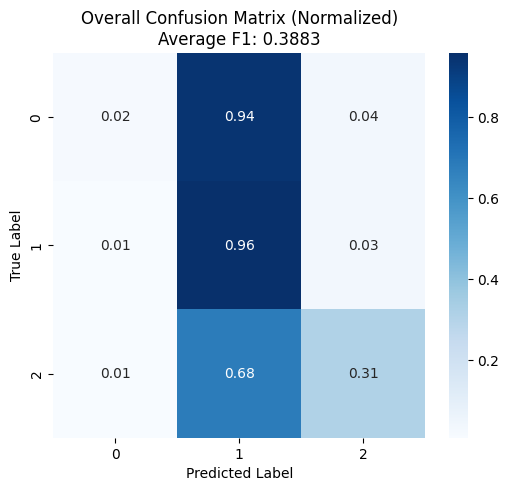


Cross-validation results
Fold F1s: [0.4111819486138761, 0.36533121515155886]
Mean Macro F1: 0.3883
Std Macro F1: 0.0229


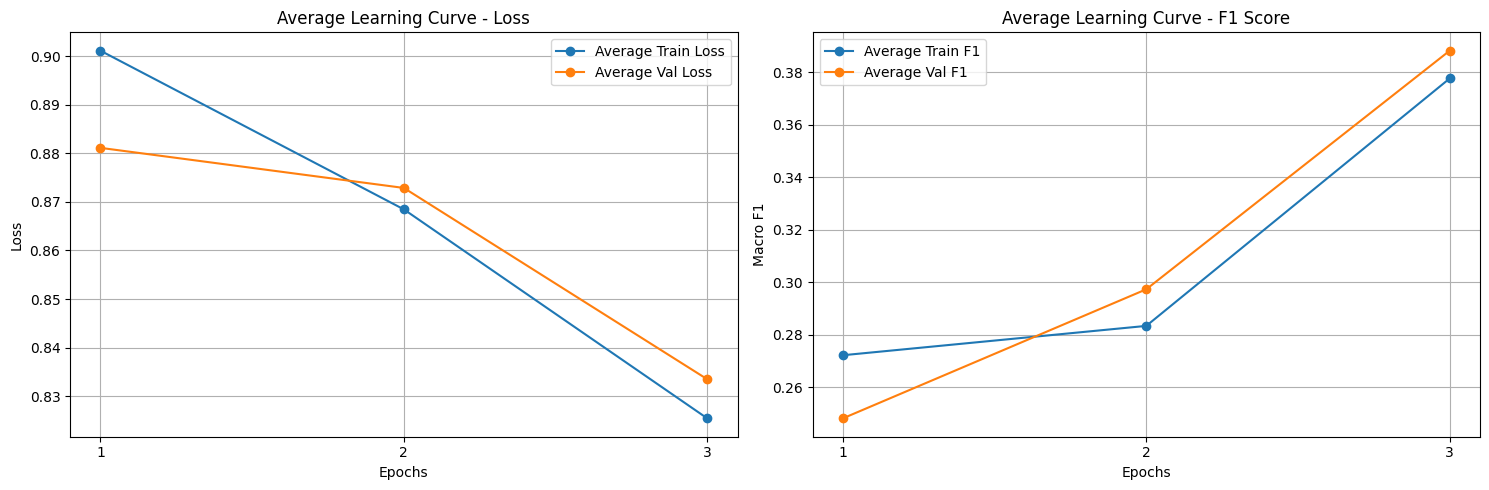

In [ ]:

# ==========================================
#  Experiment 2
# ==========================================

n_splits = 2
num_epochs = 3 
batch_size = 8
learning_rate = 1e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    torch_dtype=torch.float32
)


# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
    model.float()
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Conclusion

In Experiment 2, reducing the learning rate and using float32 precision helped resolve the NaN loss problem observed in Experiment 1. The model was able to complete the training process, and both the training and validation losses remained finite.

However, the overall classification performance was still weak. The model achieved a mean macro F1-score of 0.3883 with a standard deviation of 0.0229. This was a clear improvement compared to Experiment 1, but it was still much lower than the BERT-based experiments. The validation accuracy was approximately 0.60, while the weighted F1-score was 0.49.

The classification report and confusion matrix showed that the model mainly predicted the Ambivalent class and still struggled to correctly identify the Clear Reply and Clear Non-Reply classes. Therefore, although the changes improved numerical stability, they were not sufficient for DeBERTa to learn a balanced separation between the three classes.

## Weighted Loss and Warm-Up Scheduler Experiment

After the NaN loss problem was resolved in Experiment 2, the next issue was that the model still tended to classify most samples into the same class. Although the training process was numerically stable, the classification report showed that DeBERTa was still strongly biased towards the Ambivalent class and did not separate the three classes effectively.

For this reason, in Experiment 3, class-weighted cross-entropy loss was introduced. The goal was to encourage the model to pay more attention to the classes that were not recognized well in the previous experiments and to improve the separation between the three classes. The class weights were set to [1.3, 1.0, 1.5], giving more importance to classes 0 and 2.

In addition, a warm-up scheduler was added so that the learning rate would increase gradually at the beginning of training, making the optimization process smoother. The learning rate was further reduced to 5e-6, since the previous experiments showed that DeBERTa required smaller optimization steps to remain stable. The batch size remained 8, and the model was trained for 3 epochs using 2-fold stratified cross-validation.

#### Experiment 3

*Experimental Configuration*

The configuration consists of:

- **Number of folds:** 2
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 5 × 10⁻⁶
- **Precision:** float32
- **Optimizer:** AdamW
- **Loss function:** Class-weighted cross-entropy loss
- **Class weights:** [1.3, 1.0, 1.5]
- **Learning rate scheduler:** Linear scheduler with 10% warm-up steps
- **Primary evaluation metric:** Macro F1-score


 Starting Fold 1/2
Class weights: [1.3 1.  1.5]


`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias        

...

Epoch 1: Train Loss 0.9943 | Val Loss 0.9402 | Val F1 0.2684


Fold 2 Epoch 2:   0%|          | 0/213 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.9486 | Val Loss 0.9415 | Val F1 0.2517


Fold 2 Epoch 3:   0%|          | 0/213 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.9422 | Val Loss 0.9268 | Val F1 0.2707

 Overall Cross Validation Results  

Average Validation F1 Score: 0.3096 ± 0.0389

Fold execution times:
Fold 1: 11.10 minutes
Fold 2: 11.13 minutes

Total time for all 2 folds: 22.23 minutes
Average time per fold: 11.11 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.45      0.01      0.02      1041
           1       0.60      0.97      0.74      2009
           2       0.36      0.12      0.18       352

    accuracy                           0.59      3402
   macro avg       0.47      0.37      0.32      3402
weighted avg       0.53      0.59      0.47      3402



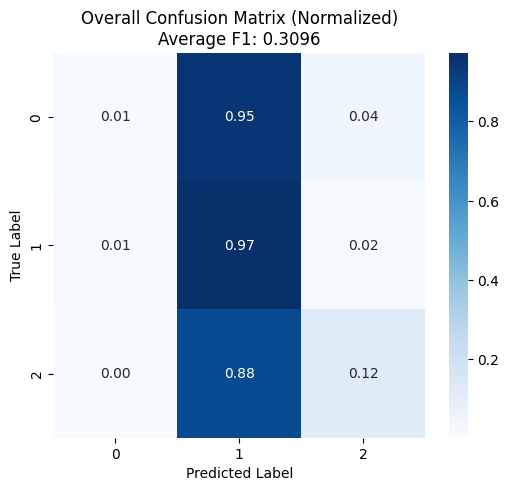


Cross-validation results
Fold F1s: [0.34854266656020344, 0.27073601653402896]
Mean Macro F1: 0.3096
Std Macro F1: 0.0389


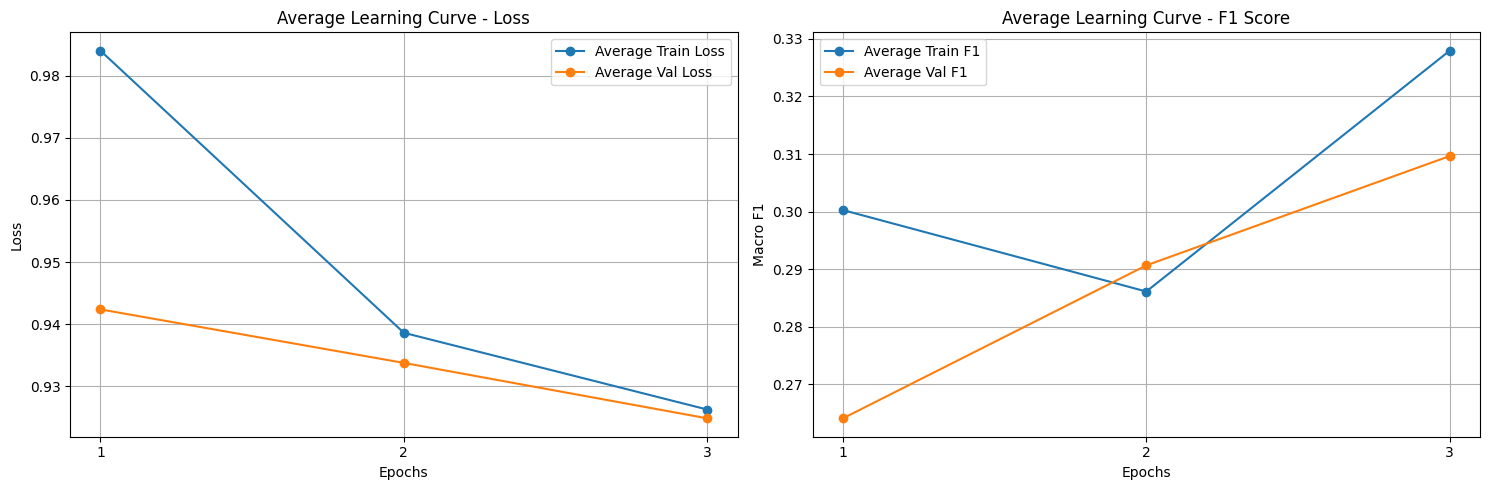

In [ ]:

# ==========================================
#  Experiment 3
# ==========================================

n_splits = 2
num_epochs = 3 
batch_size = 8
learning_rate = 5e-6


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
    class_weights = torch.tensor([1.3, 1.0, 1.5], dtype=torch.float32).to(device)
    print("Class weights:", class_weights.detach().cpu().numpy())
# model
    model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    torch_dtype=torch.float32
)


# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
    model.float()
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate,eps=1e-8)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps= int(0.1 * num_training_steps),  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Conclusion

The training process remained numerically stable and did not produce NaN losses. However, the classification performance decreased compared to Experiment 2. The model achieved a mean macro F1-score of 0.3096 with a standard deviation of 0.0389.

Although weighted loss and warm-up scheduling were introduced to improve minority-class recognition and make training smoother, they did not improve DeBERTa's performance in this configuration. The classification report showed that the model still relied heavily on one class, while the F1-scores for the other classes remained low. This indicates that the model continued to struggle with separating the three classes effectively.

The training logs showed that the loss was still decreasing by the third epoch, suggesting that the model may not have fully converged yet. Since the learning rate was reduced, the parameter updates became smaller and more gradual. While this helped stabilize the training process and avoid NaN losses, it may also have slowed down convergence. As a result, the model may have required more training epochs to fully benefit from the lower learning rate. This motivated the next experiment, where a more aggressive setup was tested with more epochs, stronger class weights, and additional stabilization through gradient clipping.

##  Multi-Factor Tuning

## Experiment 4

In Experiment 4, a more aggressive tuning strategy was tested in order to improve DeBERTa's performance. The previous experiments showed that the model could be stabilized by reducing the learning rate and using float32 precision, but it still struggled to separate the three classes effectively. In addition, Experiment 3 showed that the lower learning rate may have slowed down convergence, since the loss was still decreasing by the third epoch.

For this reason, several changes were applied together. The number of training epochs was increased to 8, allowing the model more time to learn with the reduced learning rate. Stronger class weights were also used, with values [1.8, 1.0, 1.5], because the moderate weights used in Experiment 3 were not sufficient to improve class separation. The learning rate remained low at 5e-6 to avoid the numerical instability observed in the earlier experiments.

A warm-up scheduler was kept to make the beginning of training smoother, and gradient clipping was introduced with a maximum gradient norm of 0.5. Gradient clipping was used to limit very large gradient updates and improve training stability. Therefore, this experiment combined multiple optimization and stabilization techniques: more epochs, stronger class weights, a very small learning rate, warm-up scheduling, and gradient clipping.


 Starting Fold 1/2
Class weights: [1.8 1.  1.5]


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias        

Fold 1 Epoch 1:   0%|          | 0/213 [00:00<?, ?it/s]

Gradient norm | mean: 12.3409 | max: 45.4650 | clipped batches: 213/213 (100.0%)
Epoch 1: Train Loss 0.9928 | Val Loss 0.9547 | Val F1 0.3044


...

Gradient norm | mean: 20.2843 | max: 44.0684 | clipped batches: 213/213 (100.0%)
Epoch 6: Train Loss 0.7372 | Val Loss 0.9048 | Val F1 0.5242


Fold 2 Epoch 7:   0%|          | 0/213 [00:00<?, ?it/s]

Gradient norm | mean: 22.2587 | max: 61.1917 | clipped batches: 213/213 (100.0%)
Epoch 7: Train Loss 0.6997 | Val Loss 0.9175 | Val F1 0.5247


Fold 2 Epoch 8:   0%|          | 0/213 [00:00<?, ?it/s]

Gradient norm | mean: 24.6972 | max: 203.1987 | clipped batches: 213/213 (100.0%)
Epoch 8: Train Loss 0.6570 | Val Loss 0.9224 | Val F1 0.5363

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5028 ± 0.0335

Fold execution times:
Fold 1: 29.92 minutes
Fold 2: 29.84 minutes

Total time for all 2 folds: 59.77 minutes
Average time per fold: 29.88 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.43      0.63      0.51      1041
           1       0.69      0.57      0.62      2009
           2       0.55      0.30      0.38       352

    accuracy                           0.56      3402
   macro avg       0.55      0.50      0.51      3402
weighted avg       0.59      0.56      0.56      3402



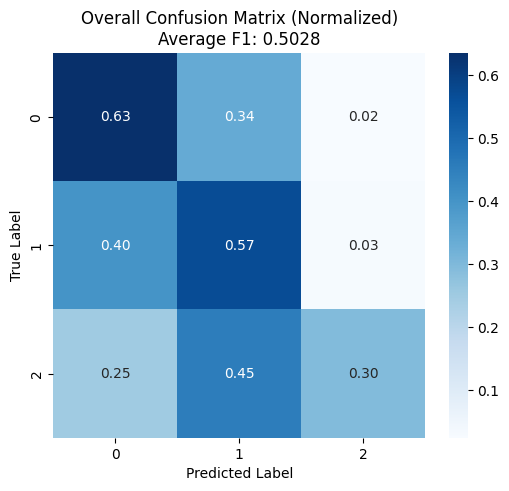


Cross-validation results
Fold F1s: [0.4692849328226773, 0.5362782434528327]
Mean Macro F1: 0.5028
Std Macro F1: 0.0335


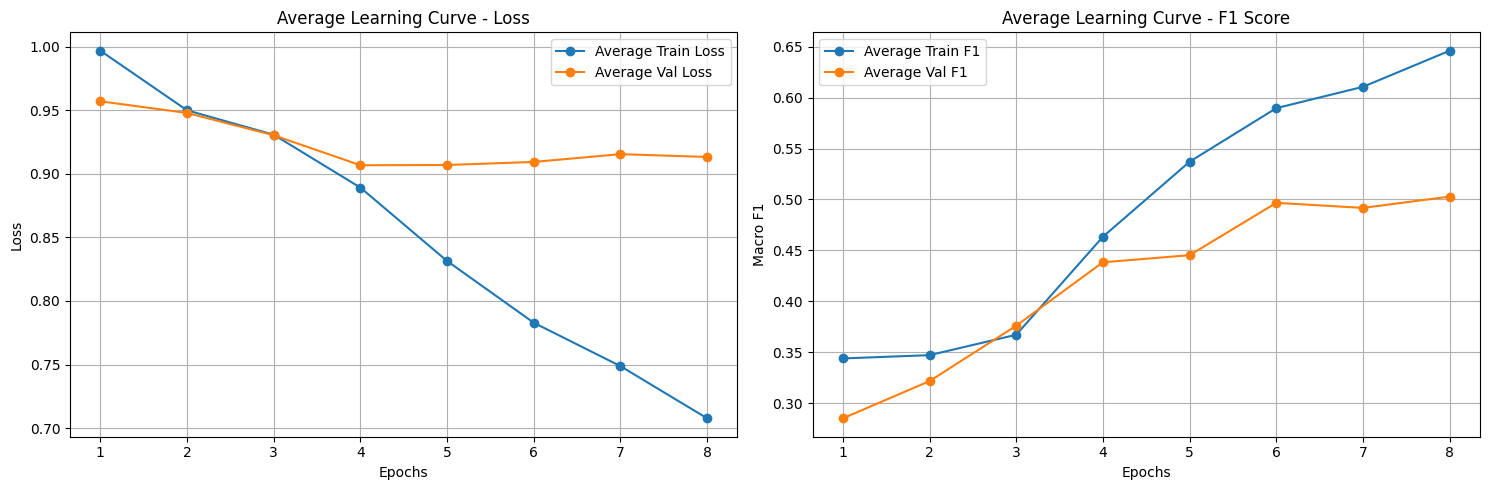

In [ ]:
# ==========================================
#  Experiment 4
# ==========================================

n_splits = 2
num_epochs = 8
batch_size = 8
learning_rate = 5e-6

max_grad_norm = 0.5

# Metrics storage
history = {
    'train_loss': [],
    'val_loss': [],
    'train_f1': [],
    'val_f1': [],
    'grad_norm_mean': [],
    'grad_norm_max': [],
    'grad_clipped_pct': []
}

fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels = []

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()

# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]

    # Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512 
    )

    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )

    class_weights = torch.tensor([1.8, 1.0, 1.5], dtype=torch.float32).to(device)
    print("Class weights:", class_weights.detach().cpu().numpy())

    # model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=3,
        torch_dtype=torch.float32
    )

    # for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)

    model.to(device)
    model.float()

    # optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate, eps=1e-8)

    # Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

    # Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)

    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=int(0.1 * num_training_steps),  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold
    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []

    # Store gradient statistics for each epoch in the current fold
    fold_grad_mean = []
    fold_grad_max = []
    fold_grad_clipped_pct = []

    # Keep the best validation F1 score for this fold
    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []

    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Gradient tracking for this epoch
        epoch_grad_norms = []
        clipped_batches = 0

        # Training loop over batches
        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation       
            
            # Gradient clipping:
            # limits very large gradient values before updating the model weights.
            # The returned grad_norm is the total norm BEFORE clipping.
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=max_grad_norm
            )

            grad_norm_value = grad_norm.detach().cpu().item()
            epoch_grad_norms.append(grad_norm_value)

            if grad_norm_value > max_grad_norm:
                clipped_batches += 1

            optimizer.step() # Update model parameters
            lr_scheduler.step() # Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss

            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)

        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")

        # Gradient statistics for the epoch
        mean_grad_norm = np.mean(epoch_grad_norms)
        max_grad_norm_epoch = np.max(epoch_grad_norms)
        pct_clipped = 100 * clipped_batches / len(train_loader)

        fold_grad_mean.append(mean_grad_norm)
        fold_grad_max.append(max_grad_norm_epoch)
        fold_grad_clipped_pct.append(pct_clipped)

        print(
            f"Gradient norm | mean: {mean_grad_norm:.4f} | "
            f"max: {max_grad_norm_epoch:.4f} | "
            f"clipped batches: {clipped_batches}/{len(train_loader)} ({pct_clipped:.1f}%)"
        )
        
        # Set the model to evaluation mode
        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item() # Add batch loss to total validation loss

                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch
        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
        print(
            f"Epoch {epoch+1}: "
            f"Train Loss {avg_train_loss:.4f} | "
            f"Val Loss {avg_val_loss:.4f} | "
            f"Val F1 {avg_val_f1:.4f}"
        )

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)

    history['grad_norm_mean'].append(fold_grad_mean)
    history['grad_norm_max'].append(fold_grad_max)
    history['grad_clipped_pct'].append(fold_grad_clipped_pct)

    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)

    del model, optimizer
    torch.cuda.empty_cache()


# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)

### Conclusion

Experiment 4 produced the best DeBERTa result among the tested configurations. The model completed training without producing NaN losses, showing that the stronger stabilization setup was effective. The use of a low learning rate, float32 precision, warm-up scheduling, and gradient clipping helped keep the training process stable.

The gradient norm logs showed that gradient clipping was applied to all batches during training. This indicates that DeBERTa produced large gradient values during fine-tuning, so gradient clipping appears to have been an important stabilization technique for controlling the size of the parameter updates.

The model achieved a mean macro F1-score of 0.5028 with a standard deviation of 0.0335 across the 2 folds. This was a clear improvement compared to the previous DeBERTa experiments, especially Experiment 3, which achieved a mean macro F1-score of 0.3096. This suggests that increasing the number of epochs, using stronger class weights, and controlling the gradients helped the model learn better decision boundaries between the classes.

The learning curves show signs of mild overfitting after the middle epochs. The training loss continued to decrease and the training macro F1-score continued to increase strongly, while the validation loss stopped improving after around epoch 4 and remained almost flat. This indicates that the model continued to fit the training data more strongly, but this did not translate into equivalent improvements on the validation set.

However, the validation macro F1-score did not decrease. Instead, it continued to improve overall and reached its highest average value at epoch 8. Therefore, training until epoch 8 was justified based on the main evaluation metric, macro F1-score. The results suggest mild overfitting or reduced generalization gains, rather than severe overfitting.

Overall, this experiment showed that DeBERTa benefited from a more careful and stronger tuning strategy. Nevertheless, the gap between the training and validation curves suggests that future experiments should use early stopping based on validation macro F1, so that training stops once the target validation metric no longer improves.

# Final Conclusion

Overall, DeBERTa-v3-base was more difficult and more time-consuming to fine-tune than the other transformer models tested in this work. The baseline experiment was unstable and produced NaN losses from the first epoch, which resulted in a very low macro F1-score of 0.1562. This showed that the initial fine-tuning configuration was not appropriate for this model.

In the following experiments, the learning rate was reduced and the model was explicitly trained using float32 precision. These changes improved numerical stability and allowed the model to complete training without NaN losses. However, even after the NaN loss problem was resolved, the model still struggled to separate the three classes effectively and often relied heavily on one class.

Compared to BERT and DistilBERT, DeBERTa required much more careful tuning to approach competitive performance. Each experiment was also more computationally expensive, especially when using cross-validation, longer sequence lengths, and multiple training epochs. Since cross-validation with DeBERTa required a large amount of training time, it was not practical to test many additional combinations of learning rates, class weights, schedulers, and epoch numbers within the available time and computational resources.

For this reason, the DeBERTa experiments were treated mainly as exploratory tuning experiments. The notebook presents the main representative experiments that were conducted in order to show the progression from numerical instability to a more stable and improved configuration. Instead of exhaustively optimizing the model, a limited number of targeted changes were tested and documented, including lower learning rates, float32 precision, class-weighted loss, warm-up scheduling, stronger class weights, more epochs, and gradient clipping.

The best DeBERTa result presented in this notebook was obtained in Experiment 4, where multiple tuning and stabilization techniques were combined. This setup used a very low learning rate, float32 precision, stronger class weights, 8 training epochs, warm-up scheduling, and gradient clipping. It achieved a mean macro F1-score of 0.5028 with a standard deviation of 0.0335 across the 2 folds. This was a clear improvement over the previous DeBERTa experiments, but it was still lower than the best BERT and DistilBERT configurations.

In conclusion, DeBERTa was not selected as the final model. Although it is a strong pretrained architecture, it required substantially more tuning time and computational resources to reach a performance level that was still below the simpler BERT-based models. With more time and resources, a more complete search using additional epochs, early stopping, and more combinations of hyperparameters could potentially improve its performance. However, within the scope of this work, DeBERTa was less efficient and less effective than the selected BERT configuration.